In [14]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [15]:
# load data using functions coded in load_mnist.py
y_train = load_mnist.load_labels(load_mnist.f_training_labels)
X_train = np.hstack((load_mnist.load_images(load_mnist.f_training_images), np.ones((len(y_train),1))))

y_test = load_mnist.load_labels(load_mnist.f_test_labels)
X_test = np.hstack((load_mnist.load_images(load_mnist.f_test_images), np.ones((len(y_test),1))))

In [30]:
def train_svm_sgd(X, y, lam, n_batch):
    """Stochastic gradient descent algorithm for classifying handwritten digits
    
    Randomly selects n_batch records from the training data and processes as a minibatch. 
    
    """
    
    # parameters for SVM-SGD algorithm
    n_total = len(y)    
    max_k = 500
    lam = 0.001

    w = np.zeros((len(X_train[0]),10))
    
    for k, e in enumerate(change_in_weights):
       
        # randomly choose indices from the original data for the minibatch
        minibatch_indices = np.random.randint(0, n_total, n_batch)
        X_batch = X_train[minibatch_indices]
        y_batch = load_mnist.digit_2_matrix(y_train[minibatch_indices])

        # diminishing tau
        tau = 1/np.sqrt(k+1)

        # calculate the indicator value
        dxw = np.multiply(y_batch, X_batch@w)    

        # calculate the gradient -- the boolean operation evaluates to 0,1
        grad_sum = -np.multiply(dxw.T<1, y_batch.T)@X_batch

        w_new = w - tau * (grad_sum.T + 2*lam/(n_total/n_batch)*w)
        w = w_new
    
    return w

# Evaluate $\lambda$

In [31]:
lam_arr = np.logspace(-5,10,20)
err_train = np.zeros(len(lam_arr))
err_test = np.zeros(len(lam_arr))

for i, lam in enumerate(lam_arr):
    
    # train the model using the training set
    w = train_svm_sgd(X_train, y_train, lam, 100)
    
    # demonstrate the model error with the training data
    y_hat = load_mnist.matrix_2_digit(X_train@w)
    err_train[i] = 1 - np.sum(y_hat==y_train) / len(y_train)
    
    # use the test set to measure error
    y_hat = load_mnist.matrix_2_digit(X_test@w)
    err_test[i] = 1 - np.sum(y_hat==y_test) / len(y_test)

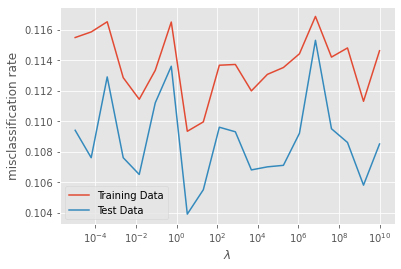

In [32]:
plt.plot(lam_arr, err_train, label='Training Data')
plt.plot(lam_arr, err_test, label='Test Data')

plt.xlabel(r'$\lambda$')
plt.ylabel('misclassification rate')

plt.semilogx()
plt.legend()

# Evaluate minibatch size

In [33]:
n_batch_arr = [10, 25, 50, 100, 250, 500, 1000]
err_train = np.zeros(len(n_batch_arr))
err_test = np.zeros(len(n_batch_arr))

for i, n in enumerate(n_batch_arr):
    
    # train the model using the training set
    w = train_svm_sgd(X_train, y_train, 0.01, n)
    
    # demonstrate the model error with the training data
    y_hat = load_mnist.matrix_2_digit(X_train@w)
    err_train[i] = 1 - np.sum(np.equal(y_hat, y_train)) / len(y_train)
    
    # use the test set to measure error
    y_hat = load_mnist.matrix_2_digit(X_test@w)
    err_test[i] = 1 - np.sum(np.equal(y_hat, y_test)) / len(y_test)

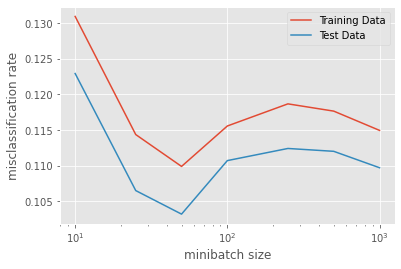

In [35]:
plt.plot(n_batch_arr, err_train, label='Training Data')
plt.plot(n_batch_arr, err_test, label='Test Data')

plt.xlabel('minibatch size')
plt.ylabel('misclassification rate')

plt.semilogx()
plt.legend()